In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [2]:
nav = pd.read_csv("../data/raw/sample_historical_nav.csv")

nav["Date"] = pd.to_datetime(nav["Date"])
nav.head()

,Scheme_Code,Date,NAV
0,120503,2020-01-01,25.35
1,120503,2021-01-01,29.87
2,120503,2022-01-01,34.15
3,120503,2023-01-01,38.92
4,120503,2024-01-01,44.68


In [ ]:
# Compute daily returns
nav_table = nav.pivot(index="Date",columns="Scheme_Code",values="NAV")
daily_returns = nav_table.pct_change()
daily_returns.head()

Scheme_Code,120503,120504,120505,120506
Date,,,,
2020-01-01,NaN,NaN,NaN,NaN
2021-01-01,0.178304,0.145494,0.174902,0.044850
2022-01-01,0.143288,0.173460,0.090788,0.167568
2023-01-01,0.139678,-0.093296,0.157283,0.092320
2024-01-01,0.147996,0.284187,0.132734,0.160558


In [4]:
daily_returns.describe()

Scheme_Code,120503,120504,120505,120506
count,5.000000,5.000000,5.000000,5.000000
mean,0.146204,0.146159,0.140833,0.120686
std,0.020509,0.143814,0.031857,0.051594
min,0.121755,-0.093296,0.090788,0.044850
25%,0.139678,0.145494,0.132734,0.092320
50%,0.143288,0.173460,0.148459,0.138131
75%,0.147996,0.220950,0.157283,0.160558
max,0.178304,0.284187,0.174902,0.167568


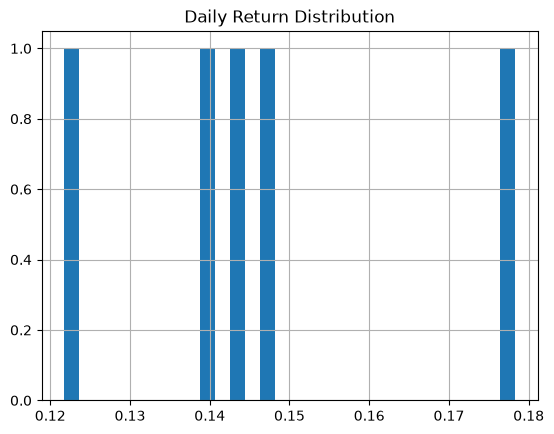

In [8]:
daily_returns[120503].hist(bins=30)

plt.title("Daily Return Distribution")
plt.show()

In [10]:
# CAGR for 1yr, 3yr, 5yr
def calculate_cagr(series, years):
    start = series.iloc[0]
    end = series.iloc[-1]
    return (end/start)**(1/years)-1

In [13]:
cagr = []

for fund in nav_table.columns:
    data = nav_table[fund].dropna()
    cagr.append({
        "scheme_code":fund,
        "CAGR_1Y":calculate_cagr(data.tail(252),1),
        "CAGR_3Y":calculate_cagr(data.tail(756),3),
        "CAGR_5Y":calculate_cagr(data.tail(1260),5)
    })

cagr_df = pd.DataFrame(cagr)
cagr_df.head()

,scheme_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,120503,0.977120,0.255098,0.146058
1,120504,0.910966,0.240941,0.138284
2,120505,0.929412,0.244921,0.140473
3,120506,0.760133,0.207393,0.119719


In [16]:
# Sharpe Ratio
rf = 0.065
sharpe=[]
for fund in daily_returns:
    ret = daily_returns[fund].dropna()
    value = ((ret.mean()-rf/252) / ret.std())*np.sqrt(252)

    sharpe.append(
        {
        "scheme_code":fund,
        "sharpe":value
        }
    )

sharpe_df=pd.DataFrame(sharpe)

sharpe_df["rank"] = (sharpe_df["sharpe"].rank(ascending=False))

sharpe_df.sort_values("rank")

,scheme_code,sharpe,rank
0,120503,112.966341,1.0
2,120505,70.048498,2.0
3,120506,37.053502,3.0
1,120504,16.104902,4.0


In [19]:
# Sortino Ratio
sortino=[]

for fund in daily_returns:
    ret=daily_returns[fund].dropna()
    downside = ret[ret<0].std()
    if downside != 0:
        value = ((ret.mean()-rf/252) / downside) * np.sqrt(252)
    else:
        value = np.nan

    sortino.append(
        {
        "scheme_code":fund,
        "sortino":value
        }
    )

sortino_df=pd.DataFrame(sortino)
sortino_df.head()

,scheme_code,sortino
0,120503,NaN
1,120504,NaN
2,120505,NaN
3,120506,NaN


In [20]:
import yfinance as yf

nifty = yf.download(
    "^CNX100",
    start="2022-01-01",
    end="2026-12-31"
)

nifty.to_csv("../data/raw/nifty100.csv")

[*********************100%***********************]  1 of 1 completed


In [23]:
nifty = pd.read_csv("../data/raw/nifty100.csv", skiprows=[1,2])
nifty.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]
nifty["Date"] = pd.to_datetime(nifty["Date"])
nifty = nifty.sort_values("Date")
nifty["nifty100_return"] = nifty["Close"].pct_change()
nifty_returns = nifty.dropna()

nifty_returns.to_csv("../data/processed/nifty100_returns.csv",index=False)

nifty_returns.head()

,Date,Close,High,Low,Open,Volume,nifty100_return
1,2022-01-04,18030.949219,18051.500000,17831.500000,17934.500000,6744900,0.008781
2,2022-01-05,18147.500000,18164.699219,17974.900391,18044.300781,7898200,0.006464
3,2022-01-06,17985.599609,18025.250000,17889.750000,17997.599609,5508600,-0.008921
4,2022-01-07,18053.949219,18140.849609,17944.400391,18035.699219,5914700,0.003800
5,2022-01-10,18229.099609,18243.250000,18109.750000,18146.199219,5439200,0.009702


In [38]:
# Alpha and Beta
nifty = pd.read_csv("../data/processed/nifty100_returns.csv")

nifty["Date"] = pd.to_datetime(nifty["Date"])
nifty = nifty.set_index("Date")

daily_returns.index = pd.to_datetime(daily_returns.index)
alpha_beta = []


for fund in daily_returns.columns:
    fund_return = daily_returns[fund].dropna()
    combined = pd.concat(
        [
            fund_return,
            nifty["nifty100_return"]
        ],
        axis=1, join="inner"
    ).dropna()

    if len(combined) > 10:
        combined.columns = ["fund_return","nifty_return"]
        result = linregress(combined["nifty_return"],combined["fund_return"])
        beta = result.slope
        alpha = result.intercept * 252
    else:
        alpha = None
        beta = None

    alpha_beta.append(
        {
            "scheme_code": fund,
            "alpha": alpha,
            "beta": beta
        }
    )

alpha_beta_df = pd.DataFrame(alpha_beta)
alpha_beta_df.to_csv("../data/processed/alpha_beta.csv",index=False)
alpha_beta_df.head()

,scheme_code,alpha,beta
0,120503,None,None
1,120504,None,None
2,120505,None,None
3,120506,None,None


In [27]:
# Maximum Drawdown
drawdown=[]

for fund in nav_table:
    prices=nav_table[fund]
    running_max=prices.cummax()
    dd=(prices/running_max)-1
    drawdown.append({
        "scheme_code":fund,
          "max_drawdown":dd.min()
    })

dd_df=pd.DataFrame(drawdown)
dd_df.head()

,scheme_code,max_drawdown
0,120503,0.000000
1,120504,-0.093296
2,120505,0.000000
3,120506,0.000000


In [34]:
# Fund Scorecard (0–100)
alpha_beta_df = pd.DataFrame(alpha_beta)
score = (cagr_df
    .merge(sharpe_df, on="scheme_code")
    .merge(alpha_beta_df, on="scheme_code")
    .merge(dd_df, on="scheme_code")
)

score["score"]= (score["CAGR_3Y"].rank(pct=True)*30 + score["sharpe"].rank(pct=True)*25 + score["alpha"].rank(pct=True)*20 - score["max_drawdown"].rank(pct=True)*15)

score.to_csv("../data/processed/fund_scorecard.csv",index=False)
score.head()

,scheme_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,sharpe,rank,alpha,beta,max_drawdown,score
0,120503,0.977120,0.255098,0.146058,112.966341,1.0,None,None,0.000000,NaN
1,120504,0.910966,0.240941,0.138284,16.104902,4.0,None,None,-0.093296,NaN
2,120505,0.929412,0.244921,0.140473,70.048498,2.0,None,None,0.000000,NaN
3,120506,0.760133,0.207393,0.119719,37.053502,3.0,None,None,0.000000,NaN


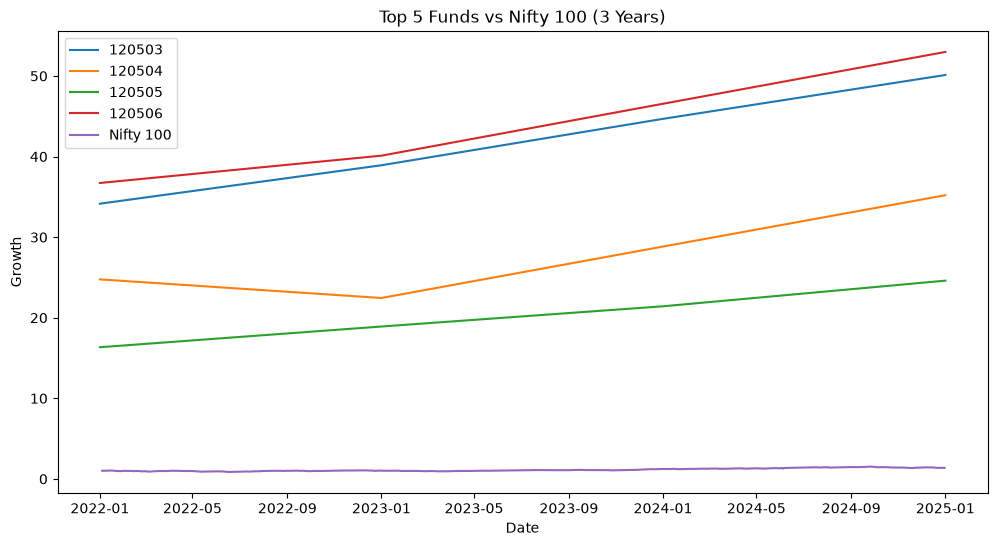

In [ ]:
# Benchmark comparison chart
top5 = score.sort_values("score",ascending=False).head(5)

end_date = nav_table.index.max()
start_date = end_date - pd.DateOffset(years=3)
nav_3y = nav_table.loc[start_date:end_date]

plt.figure(figsize=(12,6))

for fund in top5["scheme_code"]:
    plt.plot(nav_3y.index,nav_3y[fund],label=fund)


nifty = pd.read_csv("../data/processed/nifty100_returns.csv")
nifty["Date"] = pd.to_datetime(nifty["Date"])
nifty = nifty.set_index("Date")

nifty_3y = nifty.loc[start_date:end_date]

nifty_growth = ((1 + nifty_3y["nifty100_return"]).cumprod())

plt.plot(nifty_growth.index,nifty_growth,label="Nifty 100")

plt.title("Top 5 Funds vs Nifty 100 (3 Years)")
plt.xlabel("Date")
plt.ylabel("Growth")
plt.legend()

plt.savefig(
    "../charts/benchmark_comparison.png",
    bbox_inches="tight"
)


plt.show()

In [42]:
# tracking error
nav_table.index = pd.to_datetime(nav_table.index)
nifty.index = pd.to_datetime(nifty.index)

tracking_error = []
for fund in top5["scheme_code"]:
    fund_return = nav_table[fund].pct_change()
    combined = pd.concat([
            fund_return,
            nifty["nifty100_return"]
        ],axis=1,join="inner").dropna()

    combined.columns = [
        "fund_return",
        "benchmark_return"
    ]

    error = (combined["fund_return"]-combined["benchmark_return"]).std() * (252**0.5)

    tracking_error.append(
        {
            "scheme_code": fund,
            "tracking_error": error
        }
    )


tracking_error_df = pd.DataFrame(tracking_error)
tracking_error_df

,scheme_code,tracking_error
0,120503,NaN
1,120504,NaN
2,120505,NaN
3,120506,NaN
